In [2]:
# Random Forest Alpha Strategy
# Emerging Markets — Multi-Market Analysis
# Author: Shubham Sharma

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, 
                             confusion_matrix,
                             roc_curve, 
                             roc_auc_score)

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


In [3]:
# Download 5 years of data for 4 Emerging Markets
tickers = {
    "Brazil": "EWZ",
    "India": "INDA", 
    "Turkey": "TUR",
    "SouthAfrica": "EZA"
}

# Download all markets at once
raw_data = yf.download(list(tickers.values()), 
                       start="2019-01-01", 
                       end="2024-01-01")

# Keep only closing prices
prices = raw_data["Close"]

print("Data downloaded successfully ✓")
print("Shape:", prices.shape)
print("\nFirst 3 rows:")
print(prices.head(3))

[*********************100%***********************]  4 of 4 completed

Data downloaded successfully ✓
Shape: (1258, 4)

First 3 rows:
Ticker            EWZ        EZA       INDA        TUR
Date                                                  
2019-01-02  26.115139  33.774250  30.244141  19.582914
2019-01-03  26.282215  33.874985  29.628979  18.854898
2019-01-04  26.873400  35.721851  30.574680  19.877394


In [4]:
# Function to engineer features for any market
def engineer_features(price_series):
    df = pd.DataFrame()
    df["price"] = price_series
    df["return_1d"] = df["price"].pct_change()
    df["ma_5"] = df["price"].rolling(window=5).mean()
    df["ma_20"] = df["price"].rolling(window=20).mean()
    df["volatility_10"] = df["return_1d"].rolling(window=10).std()
    df["momentum_5"] = df["price"] - df["price"].shift(5)
    df["target"] = (df["price"].shift(-1) > df["price"]).astype(int)
    df = df.dropna()
    return df

# Apply function to all 4 markets
market_data = {}
for country, ticker in tickers.items():
    market_data[country] = engineer_features(prices[ticker])
    print(f"{country} → {len(market_data[country])} rows prepared ✓")

Brazil → 1239 rows prepared ✓
India → 1239 rows prepared ✓
Turkey → 1239 rows prepared ✓
SouthAfrica → 1239 rows prepared ✓


In [5]:
# Build Random Forest model for each market
# Store results for comparison

results = {}
feature_cols = ["return_1d", "ma_5", "ma_20", "volatility_10", "momentum_5"]

for country in market_data:
    # Get data for this market
    df = market_data[country]
    
    # Split features and target
    X = df[feature_cols]
    y = df["target"]
    
    # Split into train and test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )
    
    # Build and train model
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Get predictions
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)
    
    # Store results
    results[country] = {
        "accuracy": round(accuracy * 100, 2),
        "auc": round(auc, 3),
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "predictions": predictions,
        "probabilities": probabilities
    }
    
    print(f"{country}:")
    print(f"  Accuracy = {results[country]['accuracy']}%")
    print(f"  AUC Score = {results[country]['auc']}")
    print()

Brazil:
  Accuracy = 52.02%
  AUC Score = 0.525

India:
  Accuracy = 48.79%
  AUC Score = 0.491

Turkey:
  Accuracy = 51.21%
  AUC Score = 0.52

SouthAfrica:
  Accuracy = 48.39%
  AUC Score = 0.485



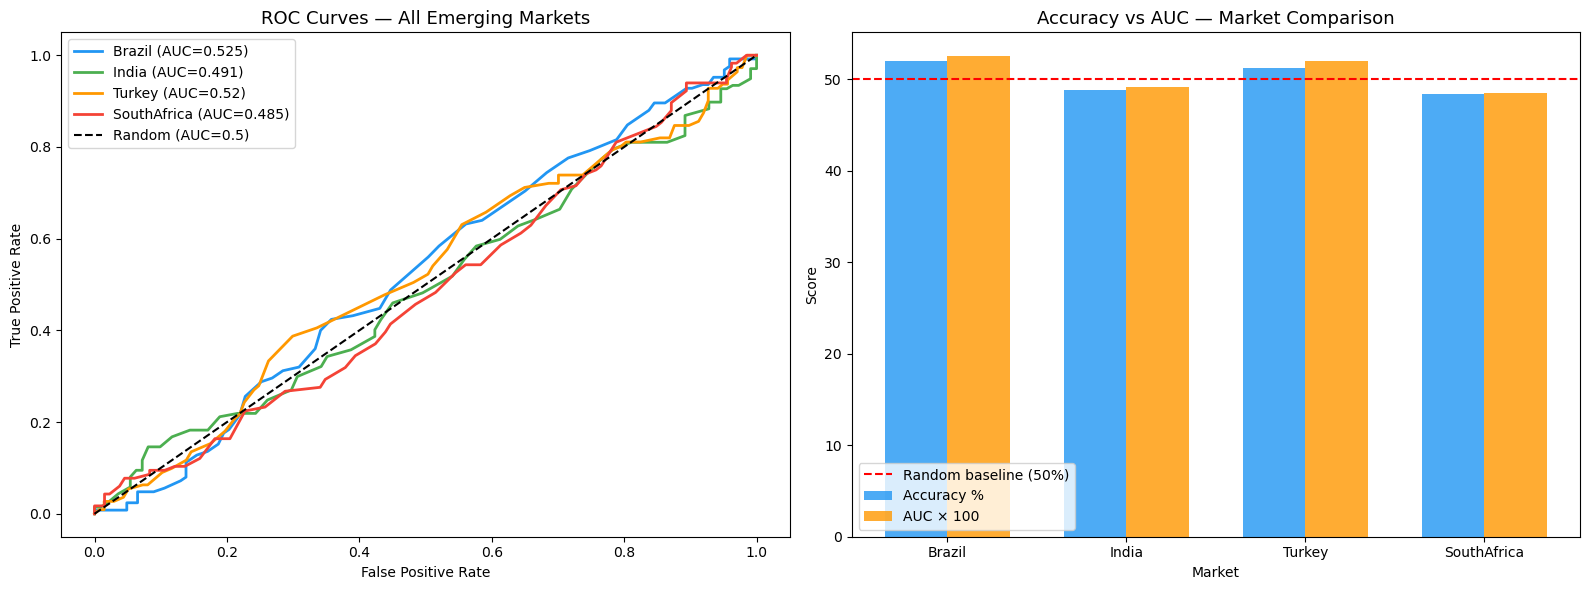

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 - ROC Curves for all markets
ax1 = axes[0]
colors = {"Brazil": "#2196F3", "India": "#4CAF50", 
          "Turkey": "#FF9800", "SouthAfrica": "#F44336"}

for country in results:
    fpr, tpr, _ = roc_curve(
        results[country]["y_test"],
        results[country]["probabilities"]
    )
    auc = results[country]["auc"]
    ax1.plot(fpr, tpr, 
             color=colors[country], 
             label=f"{country} (AUC={auc})",
             linewidth=2)

ax1.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
ax1.set_title("ROC Curves — All Emerging Markets", fontsize=13)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend()

# Chart 2 - Accuracy and AUC comparison
ax2 = axes[1]
countries = list(results.keys())
accuracies = [results[c]["accuracy"] for c in countries]
aucs = [results[c]["auc"] * 100 for c in countries]

x = np.arange(len(countries))
width = 0.35

bars1 = ax2.bar(x - width/2, accuracies, width, 
                label="Accuracy %", color="#2196F3", alpha=0.8)
bars2 = ax2.bar(x + width/2, aucs, width, 
                label="AUC × 100", color="#FF9800", alpha=0.8)

ax2.axhline(y=50, color="red", linestyle="--", label="Random baseline (50%)")
ax2.set_title("Accuracy vs AUC — Market Comparison", fontsize=13)
ax2.set_xlabel("Market")
ax2.set_ylabel("Score")
ax2.set_xticks(x)
ax2.set_xticklabels(countries)
ax2.legend()

plt.tight_layout()
plt.show()